# Surrogate model evaluation

Runs the same held-out regression evaluation as `evaluator.py`. It reports errors
by stage and feature, final-score accuracy, transmission-boundary behavior,
checkpoint provenance and the ensemble mean when multiple models are available.

This notebook only reads existing checkpoints and datasets.


In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import torch
from IPython.display import Image, Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.paths import DEFAULT_BASE_SURROGATE_DIR, DEFAULT_UPDATED_SURROGATE_DIR
from beam_optimization.env.dataset import BeamDataset
from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP
from beam_optimization.env.surrogate_env.surrogate.model.trainer import compute_normalization_metadata
from beam_optimization.env.surrogate_env.surrogate.model.evaluator import (
    evaluate_surrogate, _default_test_dataset_path, _MeanEnsemble, _checkpoint_provenance,
)


def fmt(value):
    if value is None:
        return 'n/a'
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

## Modify here

Pin one surrogate family and its matching held-out dataset below. The notebook validates their
dataset identifiers so that checkpoints trained on different datasets are never mixed silently.

In [2]:
# <-- MODIFY HERE, keeping MODEL_PATTERN and DATASET_PATH_OVERRIDE on the same dataset id.
MODEL_DIR = DEFAULT_BASE_SURROGATE_DIR / 'surrogate_031'
# e.g. MODEL_DIR = Path('beam_optimization/env/surrogate_env/surrogate/trained_models/updated')

MODEL_PATTERN = 'surrogate_031_*.pt'
DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/031/dataset_test.pt'
BUILD_ENSEMBLE_MEAN = True  # effective only when the selected family has multiple members



## 1. Checkpoints and evaluation dataset

Only checkpoints matching `MODEL_PATTERN` are evaluated. The dataset identifier encoded in every
checkpoint filename must match the parent directory of `DATASET_PATH_OVERRIDE`; otherwise execution
stops with a clear error. A mean ensemble is built only from members of that same selected family.

In [3]:
checkpoint_paths = sorted(MODEL_DIR.glob(MODEL_PATTERN)) if MODEL_DIR.exists() else []
checkpoint_source = str(MODEL_DIR) if checkpoint_paths else None

DATASET_PATH = DATASET_PATH_OVERRIDE
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Evaluation dataset not found: {DATASET_PATH}')
dataset_id = DATASET_PATH.parent.name
checkpoint_dataset_ids = {path.stem[len('surrogate_'):].rsplit('_', 1)[0] for path in checkpoint_paths}
if checkpoint_dataset_ids and checkpoint_dataset_ids != {dataset_id}:
    raise ValueError(
        f'Checkpoint/dataset mismatch: models={sorted(checkpoint_dataset_ids)}, dataset={dataset_id}. '
        'Choose one matching surrogate family and held-out split.'
    )
dataset = BeamDataset.load(DATASET_PATH)

print(f'{MODEL_DIR}: {len(checkpoint_paths)} checkpoint(s)')
print(f'evaluating {len(checkpoint_paths)} checkpoint(s) from: {checkpoint_source}')

models = []
if checkpoint_paths:
    for checkpoint_path in checkpoint_paths:
        models.append((checkpoint_path.name, ModularMLP.load(str(checkpoint_path)), checkpoint_path))
else:
    norm_stats = compute_normalization_metadata(dataset)
    models.append(('untrained (demo)', ModularMLP(norm_stats=norm_stats), None))
    print('No trained checkpoint found; evaluating a freshly initialized model.')

print('\nProvenance:')
print(f'  test dataset: {DATASET_PATH.resolve()}')
for name, _, checkpoint_path in models:
    if checkpoint_path is not None:
        provenance = _checkpoint_provenance(checkpoint_path)
        print(f"  {name}: modified={provenance['modified_utc']}, "
              f"train={provenance['train_dataset_path']}, val={provenance['val_dataset_path']}")


[BeamDataset] 12,585 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_test.pt
/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031: 1 checkpoint(s)
evaluating 1 checkpoint(s) from: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031

Provenance:
  test dataset: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_test.pt
  surrogate_031_0.pt: modified=2026-08-19T13:52:04.182243+00:00, train=beam_optimization/env/dataset/031/dataset_train.pt, val=beam_optimization/env/dataset/031/dataset_val.pt


## 2. Running `evaluate_surrogate()`

Each model is evaluated in batches on the held-out split. The report contains
native and normalized errors, final-score statistics, physical-loss and RL-terminal
subsets, and plots produced by the same implementation used by the command line.


In [4]:
all_results = {}
with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    for name, model, checkpoint_path in models:
        all_results[name] = evaluate_surrogate(
            model, dataset, plots_dir=tmp_dir, plot_prefix=Path(name).stem,
        )
        if checkpoint_path is not None:
            all_results[name]['checkpoint_provenance'] = _checkpoint_provenance(checkpoint_path)
        for plot_name, plot_path in all_results[name]['plots'].items():
            all_results[name]['plots'][plot_name] = Path(plot_path).read_bytes()

    if BUILD_ENSEMBLE_MEAN and len(models) > 1 and all(path is not None for _, _, path in models):
        ensemble = _MeanEnsemble([model for _, model, _ in models])
        all_results['ensemble_mean'] = evaluate_surrogate(
            ensemble, dataset, plots_dir=tmp_dir, plot_prefix='ensemble_mean',
        )
        all_results['ensemble_mean']['ensemble_size'] = len(models)
        for plot_name, plot_path in all_results['ensemble_mean']['plots'].items():
            all_results['ensemble_mean']['plots'][plot_name] = Path(plot_path).read_bytes()

print(f'Evaluated {len(all_results)} report(s) on {len(dataset):,} samples from {DATASET_PATH.name}.')


Evaluated 1 report(s) on 12,585 samples from dataset_test.pt.


## 3. Report, per model

### `surrogate_031_0.pt`

**Summary**

| Metric | Value |
| --- | --- |
| Samples | 12,585 |
| Physical non-failure / all lost | 10,301 / 2,284 |
| RL-valid / terminal | 6,335 / 6,250 |
| RMSE all stages | 10.2537 |
| NRMSE all stages | 1.42816 |
| RMSE final stage | 1.20865 |

**Score metrics by physical regime**

| Group | N | MAE | RMSE | Bias | Pearson r | R² |
| --- | --- | --- | --- | --- | --- | --- |
| All samples | 12,585 | 185.642 | 428.314 | 183.349 | -0.0724672 | -0.231048 |
| Physical non-failure | 10,301 | 3.89972 | 5.8219 | 1.09909 | 0.931616 | 0.854764 |
| All particles lost | 2,284 | 1005.31 | 1005.33 | 1005.31 | n/a | n/a |
| RL-valid | 6,335 | 3.21368 | 4.29417 | -0.964302 | 0.933557 | 0.864391 |
| RL-terminal | 6,250 | 370.551 | 607.769 | 370.17 | -0.663422 | -0.634584 |

**Final `npart_ratio` by operational band**

| True band | N | True mean | Predicted mean | MAE | Terminal rate |
| --- | --- | --- | --- | --- | --- |
| npart_ratio <= 0 | 2,284 | 0 | 0.0166157 | 0.0166157 | 0.989492 |
| 0 < npart_ratio < 0.1 | 3,966 | 0.0418106 | 0.0502555 | 0.0163671 | 0.903681 |
| 0.1 <= npart_ratio < 0.25 | 4,156 | 0.169181 | 0.156688 | 0.0292611 | 0.12897 |
| npart_ratio >= 0.25 | 2,179 | 0.330204 | 0.292436 | 0.0449256 | 0.0192749 |

**Per-feature errors**

| Feature | RMSE all | MAE all | RMSE final | NRMSE final |
| --- | --- | --- | --- | --- |
| `npart_ratio` | 0.0843052 | 0.0298693 | 0.040664 | 0.337355 |
| `x0` | 4.84456 | 1.04297 | 1.18786 | 0.482284 |
| `y0` | 6.72996 | 0.88508 | 0.970731 | 0.319497 |
| `SizeX` | 6.25241 | 1.15284 | 0.768913 | 0.412949 |
| `SizeY` | 6.41007 | 0.919306 | 0.919969 | 0.575765 |
| `ex` | 3.79761 | 0.269618 | 0.0227089 | 1.30187 |
| `ey` | 0.515175 | 0.0564812 | 0.018579 | 0.733587 |
| `x'0` | 27.1968 | 2.42746 | 1.96962 | 0.31862 |
| `y'0` | 6.55269 | 1.09789 | 2.33981 | 0.356551 |

**Checkpoint provenance**

| Field | Value |
| --- | --- |
| Path | /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031/surrogate_031_0.pt |
| Modified UTC | 2026-08-19T13:52:04.182243+00:00 |
| Training dataset | beam_optimization/env/dataset/031/dataset_train.pt |
| Validation dataset | beam_optimization/env/dataset/031/dataset_val.pt |
| Best validation loss | 111.027 |

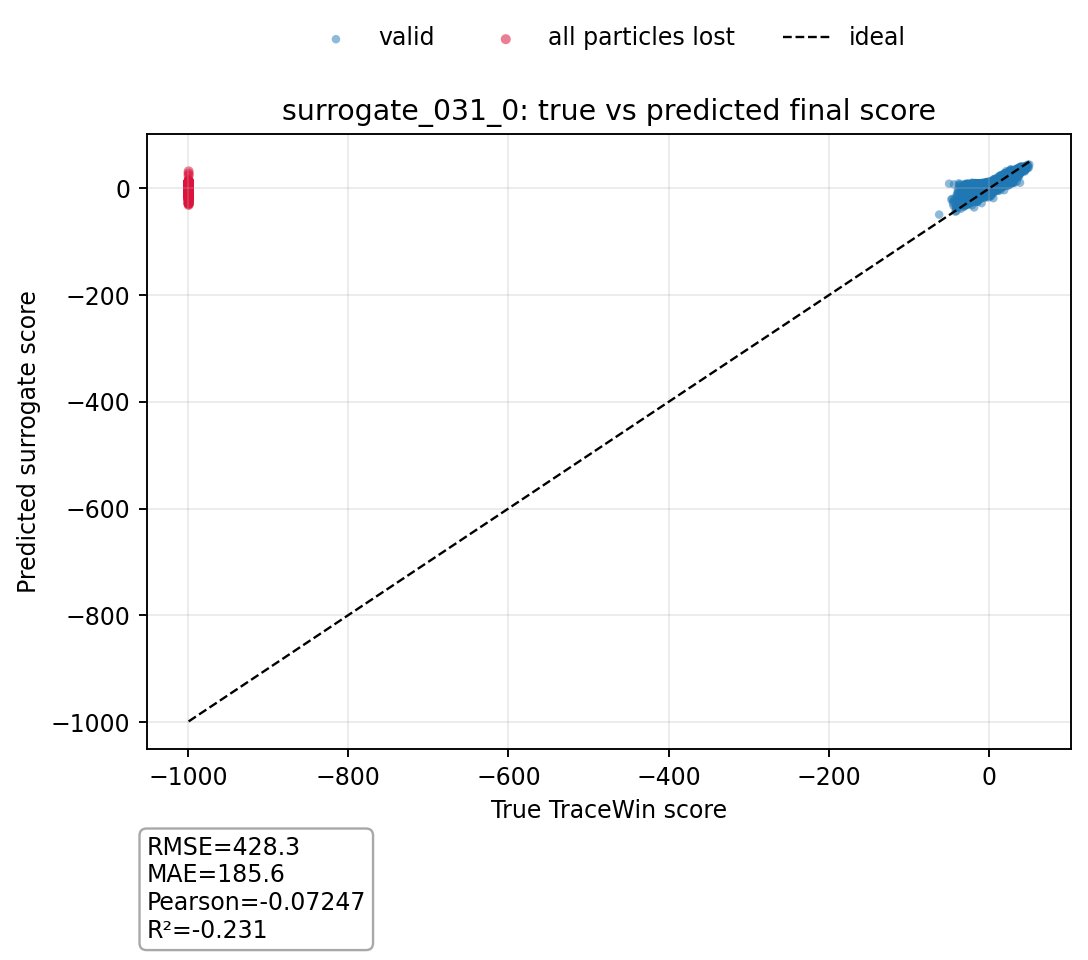

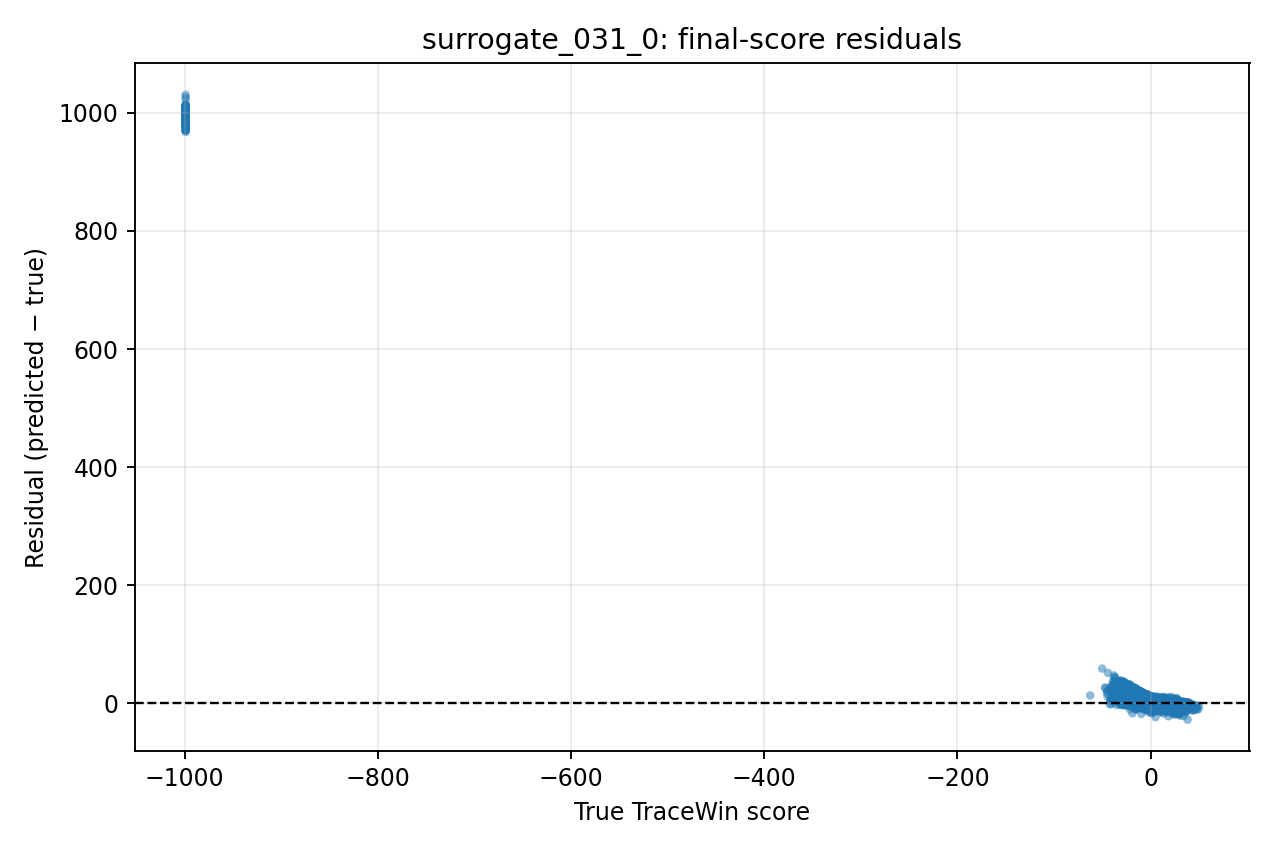

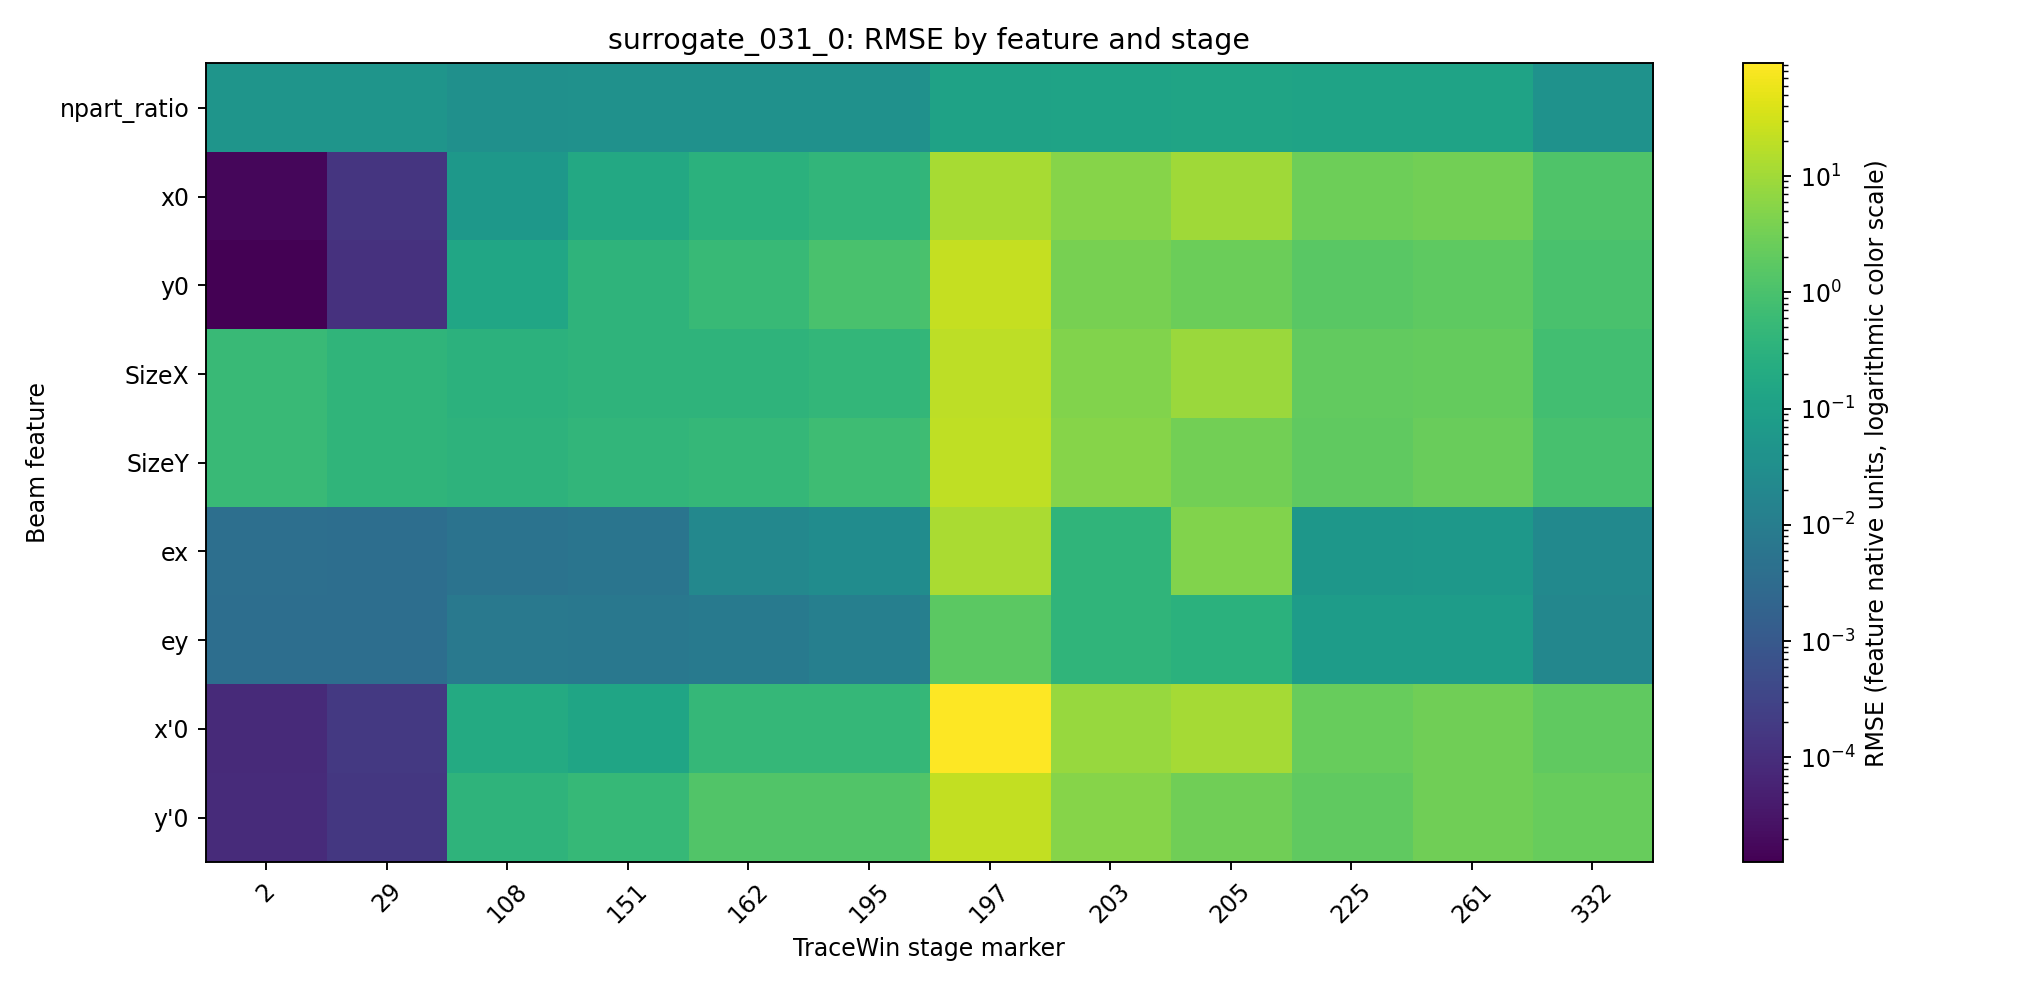

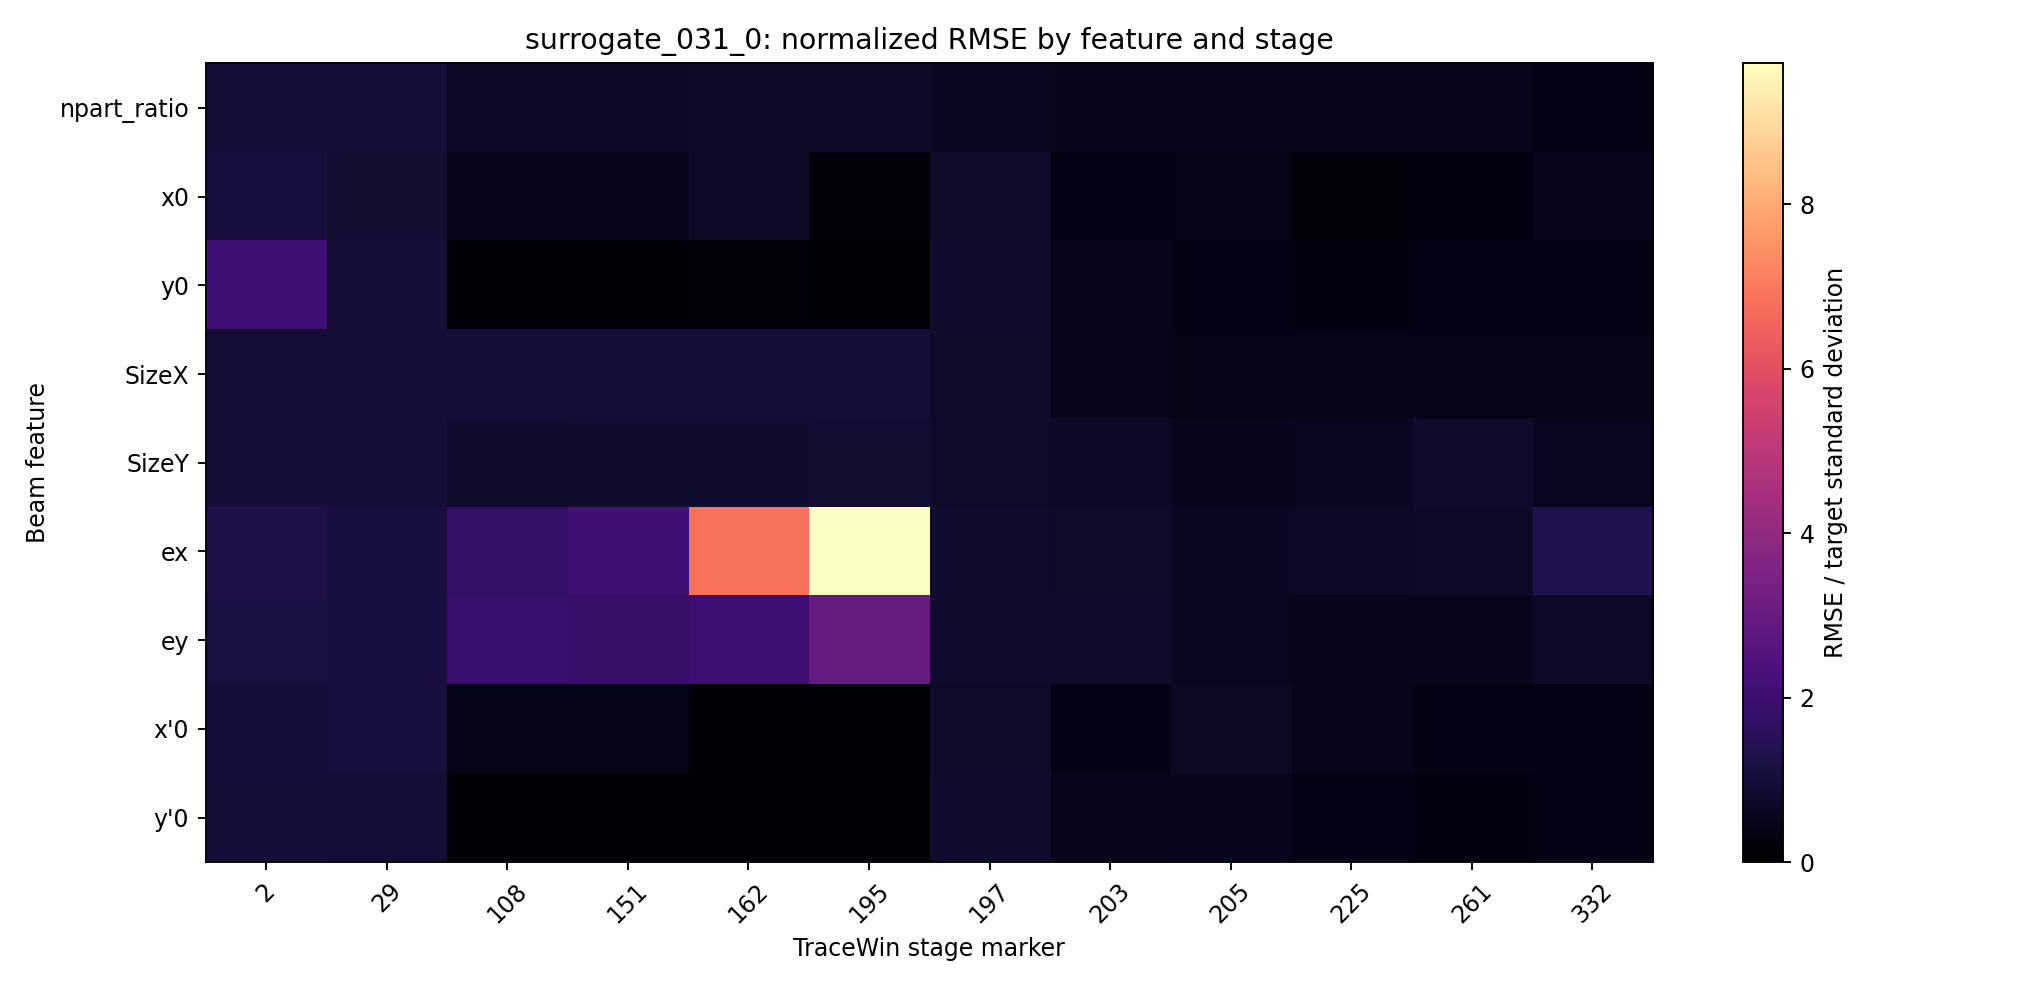

In [5]:
for name, metrics in all_results.items():
    groups = metrics['sample_groups']
    rl_groups = metrics['rl_sample_groups']
    summary_rows = [
        ['Samples', f"{metrics['n_samples']:,}"],
        ['Physical non-failure / all lost', f"{groups['n_valid']:,} / {groups['n_failures']:,}"],
        ['RL-valid / terminal', f"{rl_groups['n_valid']:,} / {rl_groups['n_terminal']:,}"],
        ['RMSE all stages', fmt(metrics['rmse_all'])],
        ['NRMSE all stages', fmt(metrics['nrmse_all'])],
        ['RMSE final stage', fmt(metrics['rmse_final_stage'])],
    ]
    score_rows = []
    for label, key, count in [
        ('All samples', 'score_metrics', metrics['n_samples']),
        ('Physical non-failure', 'score_metrics_valid', groups['n_valid']),
        ('All particles lost', 'score_metrics_failures', groups['n_failures']),
        ('RL-valid', 'score_metrics_rl_valid', rl_groups['n_valid']),
        ('RL-terminal', 'score_metrics_rl_terminal', rl_groups['n_terminal']),
    ]:
        values = metrics[key]
        score_rows.append([
            label, f'{count:,}', fmt(values['mae']), fmt(values['rmse']),
            fmt(values['bias']), fmt(values['pearson_correlation']), fmt(values['r2']),
        ])
    feature_rows = [
        [f'`{feature}`', fmt(values['rmse_all_stages']), fmt(values['mae_all_stages']),
         fmt(values['rmse_final_stage']), fmt(values['nrmse_final_stage'])]
        for feature, values in metrics['feature_metrics'].items()
    ]
    band_rows = [
        [row['interval'], f"{row['n_samples']:,}", fmt(row['true_mean']),
         fmt(row['predicted_mean']), fmt(row['mae']), fmt(row['regressor_terminal_rate'])]
        for row in metrics['npart_ratio_bands']
    ]
    sections = [
        f'### `{name}`',
        '**Summary**', table(['Metric', 'Value'], summary_rows),
        '**Score metrics by physical regime**',
        table(['Group', 'N', 'MAE', 'RMSE', 'Bias', 'Pearson r', 'R²'], score_rows),
        '**Final `npart_ratio` by operational band**',
        table(['True band', 'N', 'True mean', 'Predicted mean', 'MAE', 'Terminal rate'], band_rows),
        '**Per-feature errors**',
        table(['Feature', 'RMSE all', 'MAE all', 'RMSE final', 'NRMSE final'], feature_rows),
    ]
    provenance = metrics.get('checkpoint_provenance')
    if provenance:
        sections += ['**Checkpoint provenance**', table(['Field', 'Value'], [
            ['Path', provenance['path']], ['Modified UTC', provenance['modified_utc']],
            ['Training dataset', provenance['train_dataset_path']],
            ['Validation dataset', provenance['val_dataset_path']],
            ['Best validation loss', fmt(provenance['best_val_loss'])],
        ])]
    display(Markdown('\n\n'.join(sections)))
    for plot_name, plot_bytes in metrics['plots'].items():
        display(Image(data=plot_bytes))


## 4. Where this fits in the pipeline

- This notebook is the interactive, always-available counterpart to running
  `python -m beam_optimization.env.surrogate_env.surrogate.model.evaluator --model-dir <dir> --dataset <path>`
  directly -- same `evaluate_surrogate()` call, same numbers, just rendered here instead of written to
  `results/benchmark/surrogate_eval.json` and standalone PNGs.
- See [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) for what the model being
  evaluated actually looks like (layers, parameters, forward pass), and `trainer.py` for how a real
  checkpoint gets produced in the first place (`train_surrogate` command).
- If section 1 above evaluated an `'untrained (demo)'` model, none of the numbers or plots in this
  notebook reflect real surrogate accuracy -- re-run the notebook once a checkpoint exists under
  `trained_models/base/` or `trained_models/updated/`.